# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [1]:
!pip install cvxopt

### Package Imports

In [27]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split, 
import pandas as pd
import time
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

solvers.options['show_progress'] = False

## Accessing the Data

In [2]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [3]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [4]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


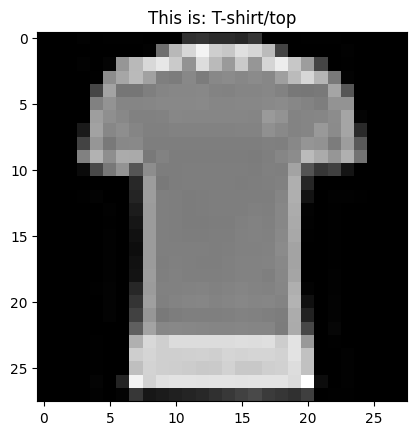

In [6]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [10]:
def nonlinear_kernel(X, y, kernel='rbf', gamma=1e-4, degree=3, coef0=0.0):
    """
    Compute kernel matrix between X and y.

    Parameters
    ----------
    X : array of shape (n1, n_features)
    y : array of shape (n2, n_features)
    kernel : 'rbf', 'poly', or 'sigmoid'
    gamma  : kernel coefficient
    degree : degree for poly kernel
    coef0  : independent term for poly/sigmoid
    """
    if kernel == 'rbf':
        sq_dists = (np.sum(X**2, axis=1, keepdims=True)
                    + np.sum(y**2, axis=1)
                    - 2 * X @ y.T)
        return np.exp(-gamma * sq_dists)
    elif kernel == 'poly':
        return (gamma * X @ y.T + coef0) ** degree
    elif kernel == 'sigmoid':
        return np.tanh(gamma * X @ y.T + coef0)
    else:
        raise ValueError(f"Unknown kernel '{kernel}'.")

In [11]:
class SVM(object):
    
    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        """
        Initialize SVM.
        Parameters
        ----------
        kernel : callable  — k(X1, X2) → (n1, n2) kernel matrix
        C      : float     — regularization / soft-margin parameter
        """
        self.kernel    = kernel
        self.C         = C
        # set after fit()
        self.alphas_sv = None
        self.X_sv      = None
        self.y_sv      = None
        self.b         = None

    def fit(self, X, y):
        """
        Fit SVM via cvxopt QP (Bishop 7.32–7.34).

        Minimise  : (1/2) aᵀ TKT a − 1ᵀa
        Subject to: G a ≤ h   (box constraint 0 ≤ aᵢ ≤ C)
                    tᵀ a = 0  (equality)
        """
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        N = X.shape[0]

        K   = self.kernel(X, X)          # (N, N)  kernel matrix
        T   = np.diag(y)                 # (N, N)  diagonal label matrix
        TKT = T @ K @ T                  # (N, N)  Bishop's quadratic form

        # P, q  → objective
        P = matrix(TKT,                    tc='d')   # (N, N)
        q = matrix(-np.ones(N),            tc='d')   # (N, 1)  –1ᵀa → minimise

        # G, h  → inequality  [I; –I] a ≤ [C·1; 0]
        #         encodes  0 ≤ aᵢ ≤ C  for all i
        G_np = np.vstack([ np.eye(N),          # aᵢ ≤ C
                           -np.eye(N)])         # –aᵢ ≤ 0  ⟺  aᵢ ≥ 0
        h_np = np.hstack([ self.C * np.ones(N),
                            np.zeros(N)])
        G = matrix(G_np, tc='d')               # (2N, N)
        h = matrix(h_np, tc='d')               # (2N, 1)

        # A, b  → equality  tᵀ a = 0
        A    = matrix(y.reshape(1, -1), tc='d')  # (1, N)
        b_eq = matrix(0.0)                       # scalar

        # ── Step 3: Solve QP ─────────────────────
        solution = solvers.qp(P, q, G, h, A, b_eq)
        alphas   = np.array(solution['x']).flatten()   # Lagrange multipliers

        # ── Step 4: Support vectors (α > threshold) ─
        sv_mask        = alphas > 1e-5
        self.alphas_sv = alphas[sv_mask]
        self.X_sv      = X[sv_mask]
        self.y_sv      = y[sv_mask]

        # ── Step 5: Bias b  (Bishop 7.37) ────────
        # b = (1/Nsv) Σₛ [ tₛ − Σₘ αₘ tₘ k(xₘ, xₛ) ]
        K_sv   = self.kernel(self.X_sv, self.X_sv)   # (Nsv, Nsv)
        self.b = np.mean(
            self.y_sv - (self.alphas_sv * self.y_sv) @ K_sv
        )

        print(f" Fit complete — {sv_mask.sum()} support vectors, b = {self.b:.4f}")
        return self

    def predict(self, X):
        """
        Predict class labels using Bishop (7.13):
            y(x) = Σᵢ αᵢ tᵢ k(xᵢ, x) + b
        Returns +1 or –1 for each sample.
        """
        X        = np.array(X, dtype=float)
        K        = self.kernel(X, self.X_sv)                # (n_test, n_sv)
        decision = K @ (self.alphas_sv * self.y_sv) + self.b  # (n_test,)
        return np.sign(decision)

    def score(self, X, y):
        """Mean accuracy of predict(X) vs true labels y."""
        y      = np.array(y, dtype=float)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [12]:
class OneVsRestSVM:
    """
    One-vs-Rest (OvR) multiclass SVM.
    Trains K binary SVMs (one per class).
    Each SVM distinguishes class k (+1) from ALL others (–1).
    Prediction: argmax over raw decision scores.
    """
    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        self.kernel      = kernel
        self.C           = C
        self.classifiers = {}   # class_label → SVM

    def fit(self, X, y):
        X       = np.array(X, dtype=float)
        y       = np.array(y)
        classes = np.unique(y)

        for k, cls in enumerate(classes):
            y_bin = np.where(y == cls, +1.0, -1.0)
            print(f"[{k+1}/{len(classes)}] OvR — class {cls} ({label_to_title[cls]}) "
                  f"vs rest  ({(y_bin==1).sum()} pos / {(y_bin==-1).sum()} neg)")
            svm = SVM(kernel=self.kernel, C=self.C)
            svm.fit(X, y_bin)
            self.classifiers[cls] = svm

        return self

    def _decision_scores(self, X):
        """Return (n_samples, n_classes) matrix of raw decision values."""
        X       = np.array(X, dtype=float)
        classes = sorted(self.classifiers.keys())
        scores  = np.column_stack([
            self.classifiers[cls].kernel(X, self.classifiers[cls].X_sv)
            @ (self.classifiers[cls].alphas_sv * self.classifiers[cls].y_sv)
            + self.classifiers[cls].b
            for cls in classes
        ])
        return scores, classes

    def predict(self, X):
        scores, classes = self._decision_scores(X)
        return np.array([classes[np.argmax(scores[i])] for i in range(len(scores))])

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))

In [13]:
class OneVsOneSVM:
    """
    One-vs-One (OvO) multiclass SVM.
    Trains C(K,2) = K*(K-1)/2 binary SVMs.
    Prediction: majority vote.
    """
    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        self.kernel      = kernel
        self.C           = C
        self.classifiers = {}   # (ci, cj) → (SVM, pos_class, neg_class)

    def fit(self, X, y):
        X       = np.array(X, dtype=float)
        y       = np.array(y)
        classes = np.unique(y)
        pairs   = [(ci, cj) for i, ci in enumerate(classes)
                             for cj in classes[i+1:]]

        for k, (ci, cj) in enumerate(pairs):
            mask  = (y == ci) | (y == cj)
            X_bin = X[mask]
            y_bin = np.where(y[mask] == ci, +1.0, -1.0)
            print(f"[{k+1}/{len(pairs)}] OvO — class {ci} ({label_to_title[ci]}) "
                  f"vs {cj} ({label_to_title[cj]})  "
                  f"({(y_bin==1).sum()} pos / {(y_bin==-1).sum()} neg)")
            svm = SVM(kernel=self.kernel, C=self.C)
            svm.fit(X_bin, y_bin)
            self.classifiers[(ci, cj)] = (svm, ci, cj)

        return self

    def predict(self, X):
        X       = np.array(X, dtype=float)
        labels  = sorted(set(c for pair in self.classifiers for c in pair))
        idx     = {lbl: i for i, lbl in enumerate(labels)}
        votes   = np.zeros((X.shape[0], len(labels)), dtype=int)

        for (ci, cj), (svm, pos_cls, neg_cls) in self.classifiers.items():
            preds = svm.predict(X)
            for k, p in enumerate(preds):
                votes[k, idx[pos_cls if p == 1 else neg_cls]] += 1

        return np.array([labels[np.argmax(votes[k])] for k in range(X.shape[0])])

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))

In [14]:
rbf_kernel = lambda A, B: nonlinear_kernel(A, B, kernel='rbf', gamma=1e-4)

# Normalise
X_tr = train_samples.values / 255.0
X_te = test_samples.values  / 255.0
y_tr = train_samples_labels.values
y_te = test_samples_labels.values

In [17]:
print("=" * 60)
print("Training ONE-VS-REST SVM")
print("=" * 60)
t0      = time.time()
ovr_svm = OneVsRestSVM(kernel=rbf_kernel, C=1.0)
ovr_svm.fit(X_tr, y_tr)
ovr_train_time = time.time() - t0

print("\n" + "=" * 60)
print("Training ONE-VS-ONE SVM")
print("=" * 60)
t0      = time.time()
ovo_svm = OneVsOneSVM(kernel=rbf_kernel, C=1.0)
ovo_svm.fit(X_tr, y_tr)
ovo_train_time = time.time() - t0

Training ONE-VS-REST SVM
[1/10] OvR — class 0 (T-shirt/top) vs rest  (197 pos / 1603 neg)
 Fit complete — 430 support vectors, b = -0.3353
[2/10] OvR — class 1 (Trouser) vs rest  (182 pos / 1618 neg)
 Fit complete — 385 support vectors, b = -0.2657
[3/10] OvR — class 2 (Pullover) vs rest  (187 pos / 1613 neg)
 Fit complete — 476 support vectors, b = -0.2671
[4/10] OvR — class 3 (Dress) vs rest  (190 pos / 1610 neg)
 Fit complete — 400 support vectors, b = -0.1969
[5/10] OvR — class 4 (Coat) vs rest  (200 pos / 1600 neg)
 Fit complete — 416 support vectors, b = -0.1493
[6/10] OvR — class 5 (Sandal) vs rest  (160 pos / 1640 neg)
 Fit complete — 355 support vectors, b = -0.0160
[7/10] OvR — class 6 (Shirt) vs rest  (188 pos / 1612 neg)
 Fit complete — 833 support vectors, b = -0.6342
[8/10] OvR — class 7 (Sneaker) vs rest  (165 pos / 1635 neg)
 Fit complete — 340 support vectors, b = -0.3237
[9/10] OvR — class 8 (Bag) vs rest  (168 pos / 1632 neg)
 Fit complete — 353 support vectors, b = 

In [18]:
print("\nEvaluating...")

t0            = time.time()
ovr_preds     = ovr_svm.predict(X_te)
ovr_pred_time = time.time() - t0
ovr_acc       = np.mean(ovr_preds == y_te)

t0            = time.time()
ovo_preds     = ovo_svm.predict(X_te)
ovo_pred_time = time.time() - t0
ovo_acc       = np.mean(ovo_preds == y_te)

# Per-class accuracy
classes = np.unique(y_te)
ovr_per_class = {c: np.mean(ovr_preds[y_te==c] == y_te[y_te==c]) for c in classes}
ovo_per_class = {c: np.mean(ovo_preds[y_te==c] == y_te[y_te==c]) for c in classes}


Evaluating...


In [19]:
print("\n" + "=" * 60)
print(f"{'Metric':<30} {'OvR':>12} {'OvO':>12}")
print("-" * 60)
print(f"{'# Classifiers trained':<30} {len(classes):>12} {len(classes)*(len(classes)-1)//2:>12}")
print(f"{'Train time (s)':<30} {ovr_train_time:>12.1f} {ovo_train_time:>12.1f}")
print(f"{'Predict time (s)':<30} {ovr_pred_time:>12.2f} {ovo_pred_time:>12.2f}")
print(f"{'Overall Accuracy':<30} {ovr_acc*100:>11.2f}% {ovo_acc*100:>11.2f}%")
print("-" * 60)
print(f"{'Per-class accuracy:':<30}")
for c in classes:
    print(f"  {label_to_title[c]:<28} {ovr_per_class[c]*100:>11.2f}% {ovo_per_class[c]*100:>11.2f}%")
print("=" * 60)


Metric                                  OvR          OvO
------------------------------------------------------------
# Classifiers trained                    10           45
Train time (s)                         87.4          7.3
Predict time (s)                       0.07         0.24
Overall Accuracy                     66.00%       73.00%
------------------------------------------------------------
Per-class accuracy:           
  T-shirt/top                        58.82%       58.82%
  Trouser                            91.67%       91.67%
  Pullover                            0.00%       65.22%
  Dress                              76.19%       80.95%
  Coat                              100.00%       66.67%
  Sandal                             88.89%      100.00%
  Shirt                               0.00%       31.58%
  Sneaker                            76.47%       73.53%
  Bag                                93.75%       81.25%
  Ankle boot                         90.91%     

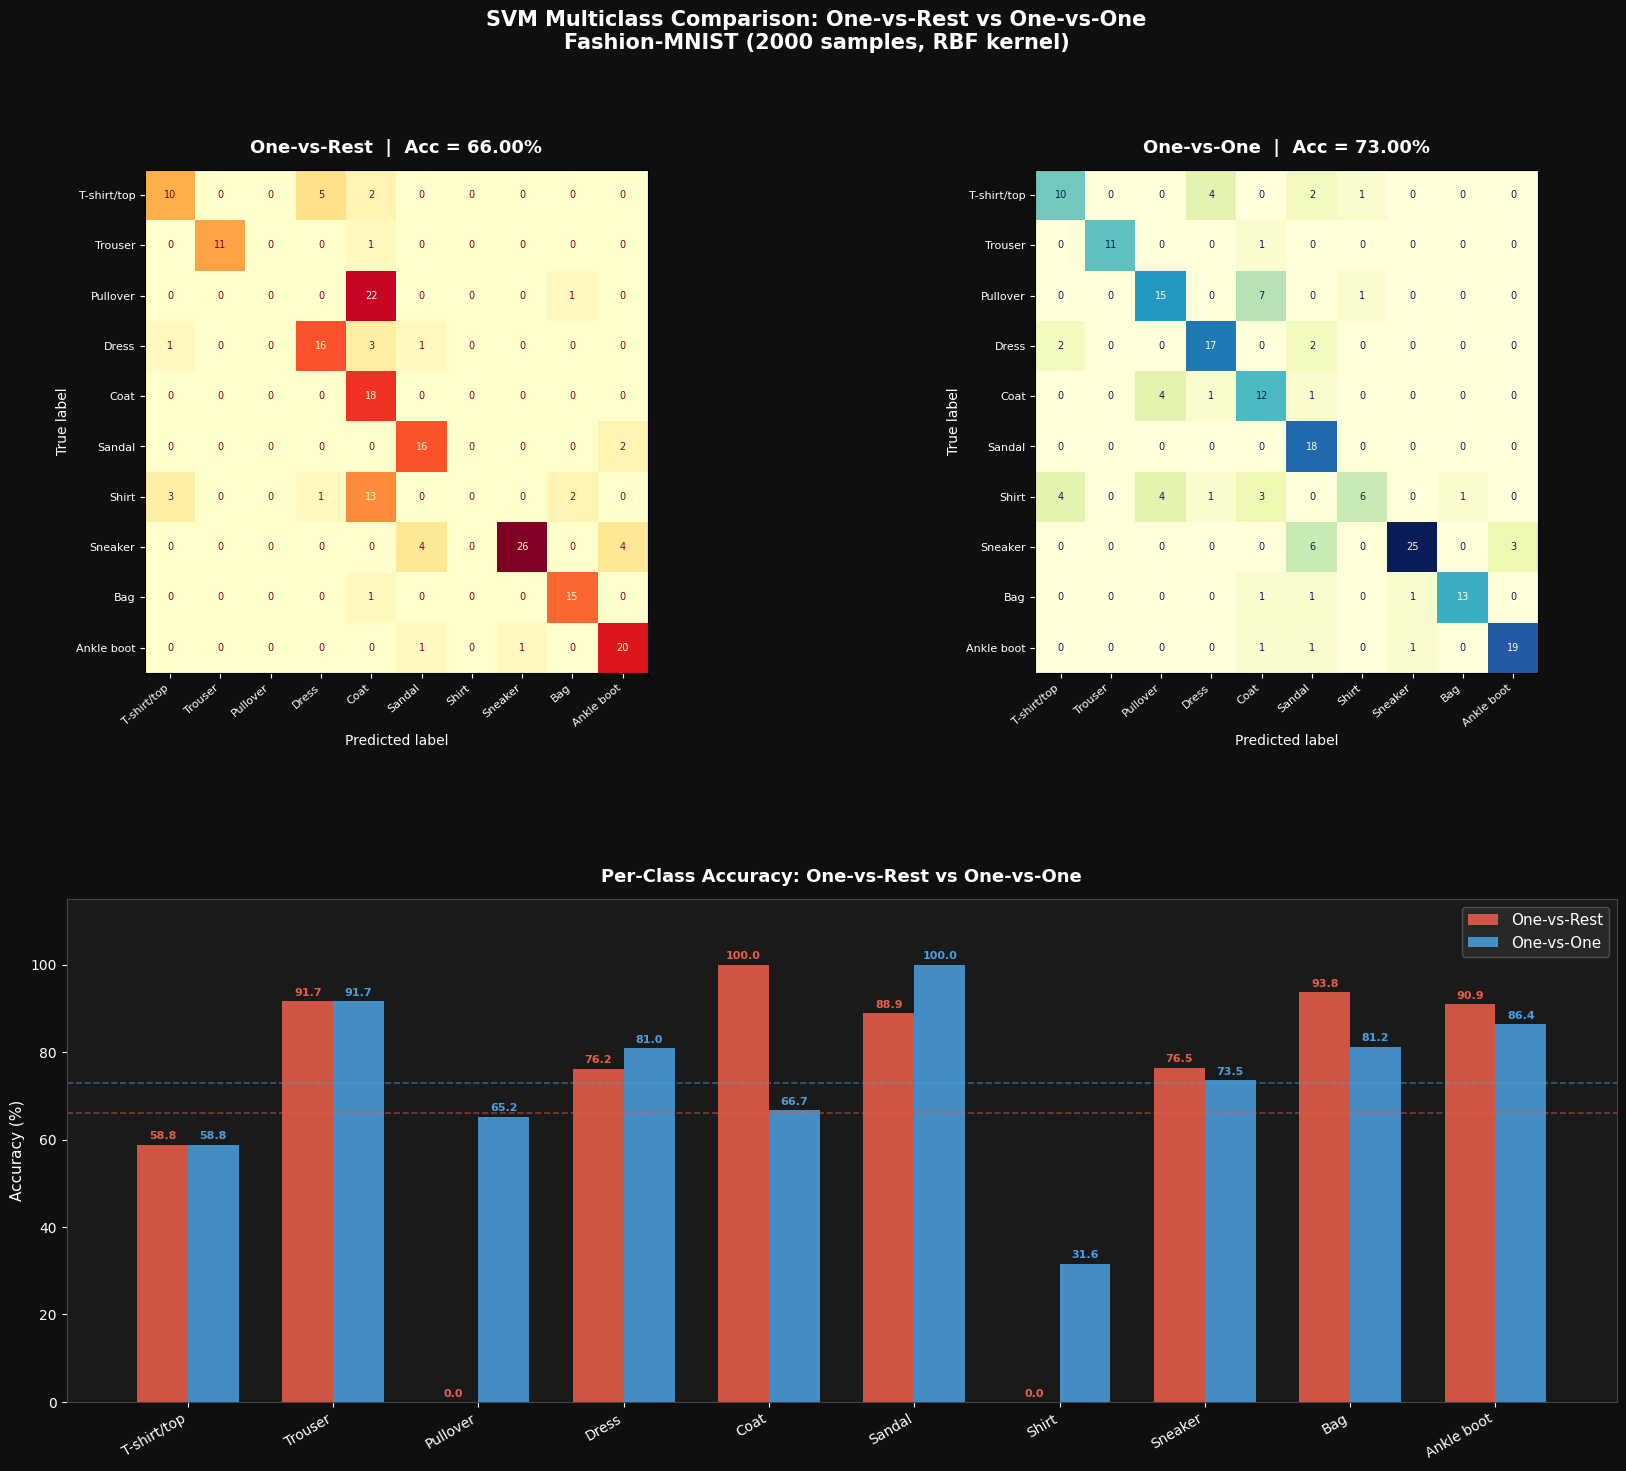

Figure saved → svm_comparison.png


In [24]:
class_names = [label_to_title[c] for c in classes]

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0f0f0f')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Confusion matrix: OvR ──
ax1 = fig.add_subplot(gs[0, 0])
cm_ovr = confusion_matrix(y_te, ovr_preds, labels=classes)
disp   = ConfusionMatrixDisplay(cm_ovr, display_labels=class_names)
disp.plot(ax=ax1, colorbar=False, cmap='YlOrRd')
ax1.set_title(f'One-vs-Rest  |  Acc = {ovr_acc*100:.2f}%',
              color='white', fontsize=13, fontweight='bold', pad=12)
ax1.tick_params(colors='white', labelsize=8)
ax1.xaxis.label.set_color('white')
ax1.yaxis.label.set_color('white')
plt.setp(ax1.get_xticklabels(), rotation=40, ha='right')
ax1.set_facecolor('#1a1a1a')
for text in disp.text_.ravel():
    text.set_fontsize(7)

# ── Confusion matrix: OvO ──
ax2 = fig.add_subplot(gs[0, 1])
cm_ovo = confusion_matrix(y_te, ovo_preds, labels=classes)
disp2  = ConfusionMatrixDisplay(cm_ovo, display_labels=class_names)
disp2.plot(ax=ax2, colorbar=False, cmap='YlGnBu')
ax2.set_title(f'One-vs-One  |  Acc = {ovo_acc*100:.2f}%',
              color='white', fontsize=13, fontweight='bold', pad=12)
ax2.tick_params(colors='white', labelsize=8)
ax2.xaxis.label.set_color('white')
ax2.yaxis.label.set_color('white')
plt.setp(ax2.get_xticklabels(), rotation=40, ha='right')
ax2.set_facecolor('#1a1a1a')
for text in disp2.text_.ravel():
    text.set_fontsize(7)

# ── Per-class accuracy bar chart ──
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#1a1a1a')
x      = np.arange(len(classes))
width  = 0.35
bars1  = ax3.bar(x - width/2,
                 [ovr_per_class[c]*100 for c in classes],
                 width, label='One-vs-Rest', color='#e85d4a', alpha=0.88)
bars2  = ax3.bar(x + width/2,
                 [ovo_per_class[c]*100 for c in classes],
                 width, label='One-vs-One',  color='#4a9edd', alpha=0.88)

# value labels on bars
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{bar.get_height():.1f}', ha='center', va='bottom',
             color='#e85d4a', fontsize=8, fontweight='bold')
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{bar.get_height():.1f}', ha='center', va='bottom',
             color='#4a9edd', fontsize=8, fontweight='bold')

ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=30, ha='right', color='white', fontsize=10)
ax3.set_ylabel('Accuracy (%)', color='white', fontsize=11)
ax3.set_title('Per-Class Accuracy: One-vs-Rest vs One-vs-One',
              color='white', fontsize=13, fontweight='bold', pad=12)
ax3.set_ylim(0, 115)
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#444')
ax3.legend(fontsize=11, facecolor='#2a2a2a', labelcolor='white',
           edgecolor='#555', framealpha=0.9)
ax3.axhline(ovr_acc*100, color='#e85d4a', linewidth=1.2,
            linestyle='--', alpha=0.5, label='_nolegend_')
ax3.axhline(ovo_acc*100, color='#4a9edd', linewidth=1.2,
            linestyle='--', alpha=0.5, label='_nolegend_')

fig.suptitle('SVM Multiclass Comparison: One-vs-Rest vs One-vs-One\nFashion-MNIST (2000 samples, RBF kernel)',
             color='white', fontsize=15, fontweight='bold', y=0.98)

plt.savefig('svm_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Figure saved → svm_comparison.png")

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [25]:
TUNE_SAMPLES = 400
FOLDS        = 3

# Stratified subsample
rng          = np.random.default_rng(42)
classes_u    = np.unique(y_tr)
tune_idx     = np.hstack([
    rng.choice(np.where(y_tr == c)[0],
               size=TUNE_SAMPLES // len(classes_u),
               replace=False)
    for c in classes_u
])
rng.shuffle(tune_idx)
X_tune = X_tr[tune_idx]
y_tune = y_tr[tune_idx]

print(f"Tuning subset: {X_tune.shape[0]} samples, "
      f"{FOLDS}-fold CV, {len(classes_u)} classes\n")

C_values = np.logspace(-1, 4, 12)   # 0.1 → 10000
print("C values to evaluate:")
print([f"{c:.3g}" for c in C_values], "\n")

Tuning subset: 400 samples, 3-fold CV, 10 classes

C values to evaluate:
['0.1', '0.285', '0.811', '2.31', '6.58', '18.7', '53.4', '152', '433', '1.23e+03', '3.51e+03', '1e+04'] 



In [30]:
# ─────────────────────────────────────────────────────────────────
# Cross-validated OvR accuracy for each C
# ─────────────────────────────────────────────────────────────────
rbf_k      = lambda A, B: nonlinear_kernel(A, B, kernel='rbf', gamma=1e-4)
skf        = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

cv_means   = []
cv_stds    = []

for C in C_values:
    fold_accs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tune, y_tune)):
        X_cv_tr, X_cv_val = X_tune[tr_idx], X_tune[val_idx]
        y_cv_tr, y_cv_val = y_tune[tr_idx], y_tune[val_idx]

        # OvR on this fold
        ovr = OneVsRestSVM(kernel=rbf_k, C=C)
        ovr.fit(X_cv_tr, y_cv_tr)
        acc = ovr.score(X_cv_val, y_cv_val)
        fold_accs.append(acc)
        print(f"  C={C:>10.3g}  fold {fold+1}/{FOLDS}  acc={acc*100:.2f}%")

    cv_means.append(np.mean(fold_accs))
    cv_stds.append(np.std(fold_accs))
    print(f"  → mean={np.mean(fold_accs)*100:.2f}%  std={np.std(fold_accs)*100:.2f}%\n")

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

[1/10] OvR — class 0 (T-shirt/top) vs rest  (26 pos / 240 neg)
 Fit complete — 65 support vectors, b = -0.2049
[2/10] OvR — class 1 (Trouser) vs rest  (27 pos / 239 neg)
 Fit complete — 60 support vectors, b = -0.1057
[3/10] OvR — class 2 (Pullover) vs rest  (26 pos / 240 neg)
 Fit complete — 84 support vectors, b = -0.3805
[4/10] OvR — class 3 (Dress) vs rest  (27 pos / 239 neg)
 Fit complete — 66 support vectors, b = -0.1844
[5/10] OvR — class 4 (Coat) vs rest  (26 pos / 240 neg)
 Fit complete — 72 support vectors, b = -0.2795
[6/10] OvR — class 5 (Sandal) vs rest  (27 pos / 239 neg)
 Fit complete — 73 support vectors, b = -0.2588
[7/10] OvR — class 6 (Shirt) vs rest  (27 pos / 239 neg)
 Fit complete — 118 support vectors, b = -0.5445
[8/10] OvR — class 7 (Sneaker) vs rest  (27 pos / 239 neg)
 Fit complete — 118 support vectors, b = -0.5466
[9/10] OvR — class 8 (Bag) vs rest  (27 pos / 239 neg)
 Fit complete — 116 support vectors, b = -0.5367
[10/10] OvR — class 9 (Ankle boot) vs res

 Fit complete — 87 support vectors, b = -0.4220
[6/10] OvR — class 5 (Sandal) vs rest  (27 pos / 240 neg)
 Fit complete — 95 support vectors, b = -0.4168
[7/10] OvR — class 6 (Shirt) vs rest  (26 pos / 241 neg)
 Fit complete — 119 support vectors, b = -0.5719
[8/10] OvR — class 7 (Sneaker) vs rest  (26 pos / 241 neg)
 Fit complete — 63 support vectors, b = -0.2023
[9/10] OvR — class 8 (Bag) vs rest  (26 pos / 241 neg)
 Fit complete — 59 support vectors, b = -0.1229
[10/10] OvR — class 9 (Ankle boot) vs rest  (27 pos / 240 neg)
 Fit complete — 67 support vectors, b = -0.2467
  C=     0.811  fold 2/3  acc=24.81%
[1/10] OvR — class 0 (T-shirt/top) vs rest  (27 pos / 240 neg)
 Fit complete — 78 support vectors, b = -0.3485
[2/10] OvR — class 1 (Trouser) vs rest  (26 pos / 241 neg)
 Fit complete — 59 support vectors, b = -0.1445
[3/10] OvR — class 2 (Pullover) vs rest  (27 pos / 240 neg)
 Fit complete — 67 support vectors, b = -0.1877
[4/10] OvR — class 3 (Dress) vs rest  (26 pos / 241 neg)

 Fit complete — 99 support vectors, b = -0.5287
[10/10] OvR — class 9 (Ankle boot) vs rest  (27 pos / 240 neg)
 Fit complete — 61 support vectors, b = -0.5876
  C=      6.58  fold 3/3  acc=67.67%
  → mean=67.99%  std=4.69%

[1/10] OvR — class 0 (T-shirt/top) vs rest  (26 pos / 240 neg)
 Fit complete — 65 support vectors, b = -1.0859
[2/10] OvR — class 1 (Trouser) vs rest  (27 pos / 239 neg)
 Fit complete — 56 support vectors, b = -0.9475
[3/10] OvR — class 2 (Pullover) vs rest  (26 pos / 240 neg)
 Fit complete — 183 support vectors, b = -0.4483
[4/10] OvR — class 3 (Dress) vs rest  (27 pos / 239 neg)
 Fit complete — 68 support vectors, b = -0.6616
[5/10] OvR — class 4 (Coat) vs rest  (26 pos / 240 neg)
 Fit complete — 91 support vectors, b = -0.6969
[6/10] OvR — class 5 (Sandal) vs rest  (27 pos / 239 neg)
 Fit complete — 84 support vectors, b = -0.0308
[7/10] OvR — class 6 (Shirt) vs rest  (27 pos / 239 neg)
 Fit complete — 109 support vectors, b = -0.8396
[8/10] OvR — class 7 (Sneake

 Fit complete — 75 support vectors, b = 0.7372
[4/10] OvR — class 3 (Dress) vs rest  (27 pos / 240 neg)
 Fit complete — 63 support vectors, b = -1.0314
[5/10] OvR — class 4 (Coat) vs rest  (27 pos / 240 neg)
 Fit complete — 60 support vectors, b = -5.8657
[6/10] OvR — class 5 (Sandal) vs rest  (27 pos / 240 neg)
 Fit complete — 62 support vectors, b = 1.6574
[7/10] OvR — class 6 (Shirt) vs rest  (26 pos / 241 neg)
 Fit complete — 134 support vectors, b = -2.1029
[8/10] OvR — class 7 (Sneaker) vs rest  (26 pos / 241 neg)
 Fit complete — 85 support vectors, b = -1.9292
[9/10] OvR — class 8 (Bag) vs rest  (26 pos / 241 neg)
 Fit complete — 67 support vectors, b = -1.7078
[10/10] OvR — class 9 (Ankle boot) vs rest  (27 pos / 240 neg)
 Fit complete — 46 support vectors, b = -4.5926
  C=       152  fold 2/3  acc=78.95%
[1/10] OvR — class 0 (T-shirt/top) vs rest  (27 pos / 240 neg)
 Fit complete — 67 support vectors, b = -5.5628
[2/10] OvR — class 1 (Trouser) vs rest  (26 pos / 241 neg)
 Fit 

 Fit complete — 245 support vectors, b = -9.8767
[8/10] OvR — class 7 (Sneaker) vs rest  (27 pos / 240 neg)
 Fit complete — 45 support vectors, b = -2.6545
[9/10] OvR — class 8 (Bag) vs rest  (27 pos / 240 neg)
 Fit complete — 80 support vectors, b = -4.2129
[10/10] OvR — class 9 (Ankle boot) vs rest  (27 pos / 240 neg)
 Fit complete — 51 support vectors, b = -6.2341
  C=  1.23e+03  fold 3/3  acc=80.45%
  → mean=79.00%  std=1.23%

[1/10] OvR — class 0 (T-shirt/top) vs rest  (26 pos / 240 neg)
 Fit complete — 54 support vectors, b = -5.9526
[2/10] OvR — class 1 (Trouser) vs rest  (27 pos / 239 neg)
 Fit complete — 29 support vectors, b = -2.2059
[3/10] OvR — class 2 (Pullover) vs rest  (26 pos / 240 neg)
 Fit complete — 76 support vectors, b = -1.7215
[4/10] OvR — class 3 (Dress) vs rest  (27 pos / 239 neg)
 Fit complete — 62 support vectors, b = -4.5095
[5/10] OvR — class 4 (Coat) vs rest  (26 pos / 240 neg)
 Fit complete — 144 support vectors, b = -1.3429
[6/10] OvR — class 5 (Sandal)

In [31]:
# ─────────────────────────────────────────────────────────────────
# Best C
# ─────────────────────────────────────────────────────────────────
best_idx = np.argmax(cv_means)
best_C   = C_values[best_idx]
print("=" * 50)
print(f"Best C = {best_C:.3g}  "
      f"(CV acc = {cv_means[best_idx]*100:.2f}% "
      f"± {cv_stds[best_idx]*100:.2f}%)")
print("=" * 50)

Best C = 433  (CV acc = 79.00% ± 0.98%)


In [33]:
# ─────────────────────────────────────────────────────────────────
# Fine-grained search around best_C
# ─────────────────────────────────────────────────────────────────
print(f"\nFine search around C={best_C:.3g} ...")
C_fine     = np.logspace(np.log10(best_C) - 0.5,
                          np.log10(best_C) + 0.5, 8)
cv_fine_m  = []
cv_fine_s  = []

for C in C_fine:
    fold_accs = []
    for tr_idx, val_idx in skf.split(X_tune, y_tune):
        X_cv_tr, X_cv_val = X_tune[tr_idx], X_tune[val_idx]
        y_cv_tr, y_cv_val = y_tune[tr_idx], y_tune[val_idx]
        ovr = OneVsRestSVM(kernel=rbf_k, C=C)
        ovr.fit(X_cv_tr, y_cv_tr)
        fold_accs.append(ovr.score(X_cv_val, y_cv_val))
    cv_fine_m.append(np.mean(fold_accs))
    cv_fine_s.append(np.std(fold_accs))
    print(f"  C={C:>10.4g}  acc={np.mean(fold_accs)*100:.2f}% "
          f"± {cv_fine_s[-1]*100:.2f}%")

cv_fine_m = np.array(cv_fine_m)
cv_fine_s = np.array(cv_fine_s)
best_fine_C = C_fine[np.argmax(cv_fine_m)]
print(f"\n✓ Final best C = {best_fine_C:.4g}")


Fine search around C=433 ...
[1/10] OvR — class 0 (T-shirt/top) vs rest  (26 pos / 240 neg)
 Fit complete — 132 support vectors, b = -2.9779
[2/10] OvR — class 1 (Trouser) vs rest  (27 pos / 239 neg)
 Fit complete — 30 support vectors, b = -1.8714
[3/10] OvR — class 2 (Pullover) vs rest  (26 pos / 240 neg)
 Fit complete — 77 support vectors, b = 0.5964
[4/10] OvR — class 3 (Dress) vs rest  (27 pos / 239 neg)
 Fit complete — 56 support vectors, b = -1.9376
[5/10] OvR — class 4 (Coat) vs rest  (26 pos / 240 neg)
 Fit complete — 90 support vectors, b = -1.6001
[6/10] OvR — class 5 (Sandal) vs rest  (27 pos / 239 neg)
 Fit complete — 65 support vectors, b = 1.1055
[7/10] OvR — class 6 (Shirt) vs rest  (27 pos / 239 neg)
 Fit complete — 104 support vectors, b = -2.9361
[8/10] OvR — class 7 (Sneaker) vs rest  (27 pos / 239 neg)
 Fit complete — 54 support vectors, b = -3.1417
[9/10] OvR — class 8 (Bag) vs rest  (27 pos / 239 neg)
 Fit complete — 97 support vectors, b = -2.2666
[10/10] OvR — 

 Fit complete — 63 support vectors, b = -2.1598
[10/10] OvR — class 9 (Ankle boot) vs rest  (27 pos / 240 neg)
 Fit complete — 47 support vectors, b = -6.2172
[1/10] OvR — class 0 (T-shirt/top) vs rest  (27 pos / 240 neg)
 Fit complete — 83 support vectors, b = -7.7065
[2/10] OvR — class 1 (Trouser) vs rest  (26 pos / 241 neg)
 Fit complete — 43 support vectors, b = -0.5858
[3/10] OvR — class 2 (Pullover) vs rest  (27 pos / 240 neg)
 Fit complete — 67 support vectors, b = -0.6275
[4/10] OvR — class 3 (Dress) vs rest  (26 pos / 241 neg)
 Fit complete — 115 support vectors, b = -4.7539
[5/10] OvR — class 4 (Coat) vs rest  (27 pos / 240 neg)
 Fit complete — 81 support vectors, b = -2.1545
[6/10] OvR — class 5 (Sandal) vs rest  (26 pos / 241 neg)
 Fit complete — 59 support vectors, b = -1.2612
[7/10] OvR — class 6 (Shirt) vs rest  (27 pos / 240 neg)
 Fit complete — 111 support vectors, b = -1.6293
[8/10] OvR — class 7 (Sneaker) vs rest  (27 pos / 240 neg)
 Fit complete — 48 support vectors

 Fit complete — 67 support vectors, b = -4.1841
[6/10] OvR — class 5 (Sandal) vs rest  (27 pos / 239 neg)
 Fit complete — 74 support vectors, b = 3.8423
[7/10] OvR — class 6 (Shirt) vs rest  (27 pos / 239 neg)
 Fit complete — 108 support vectors, b = -11.8006
[8/10] OvR — class 7 (Sneaker) vs rest  (27 pos / 239 neg)
 Fit complete — 56 support vectors, b = -6.7893
[9/10] OvR — class 8 (Bag) vs rest  (27 pos / 239 neg)
 Fit complete — 69 support vectors, b = -3.3854
[10/10] OvR — class 9 (Ankle boot) vs rest  (26 pos / 240 neg)
 Fit complete — 47 support vectors, b = -4.3735
[1/10] OvR — class 0 (T-shirt/top) vs rest  (27 pos / 240 neg)
 Fit complete — 55 support vectors, b = -1.8324
[2/10] OvR — class 1 (Trouser) vs rest  (27 pos / 240 neg)
 Fit complete — 45 support vectors, b = -1.3803
[3/10] OvR — class 2 (Pullover) vs rest  (27 pos / 240 neg)
 Fit complete — 68 support vectors, b = -4.2270
[4/10] OvR — class 3 (Dress) vs rest  (27 pos / 240 neg)
 Fit complete — 62 support vectors, 

 Fit complete — 37 support vectors, b = -0.4252
[3/10] OvR — class 2 (Pullover) vs rest  (27 pos / 240 neg)
 Fit complete — 74 support vectors, b = -1.9566
[4/10] OvR — class 3 (Dress) vs rest  (26 pos / 241 neg)
 Fit complete — 69 support vectors, b = -8.8524
[5/10] OvR — class 4 (Coat) vs rest  (27 pos / 240 neg)
 Fit complete — 69 support vectors, b = -1.7847
[6/10] OvR — class 5 (Sandal) vs rest  (26 pos / 241 neg)
 Fit complete — 95 support vectors, b = -3.7336
[7/10] OvR — class 6 (Shirt) vs rest  (27 pos / 240 neg)
 Fit complete — 98 support vectors, b = -11.6975
[8/10] OvR — class 7 (Sneaker) vs rest  (27 pos / 240 neg)
 Fit complete — 64 support vectors, b = -2.6146
[9/10] OvR — class 8 (Bag) vs rest  (27 pos / 240 neg)
 Fit complete — 72 support vectors, b = -4.2255
[10/10] OvR — class 9 (Ankle boot) vs rest  (27 pos / 240 neg)
 Fit complete — 36 support vectors, b = -6.2525
  C=      1369  acc=78.25% ± 1.65%

✓ Final best C = 367.2


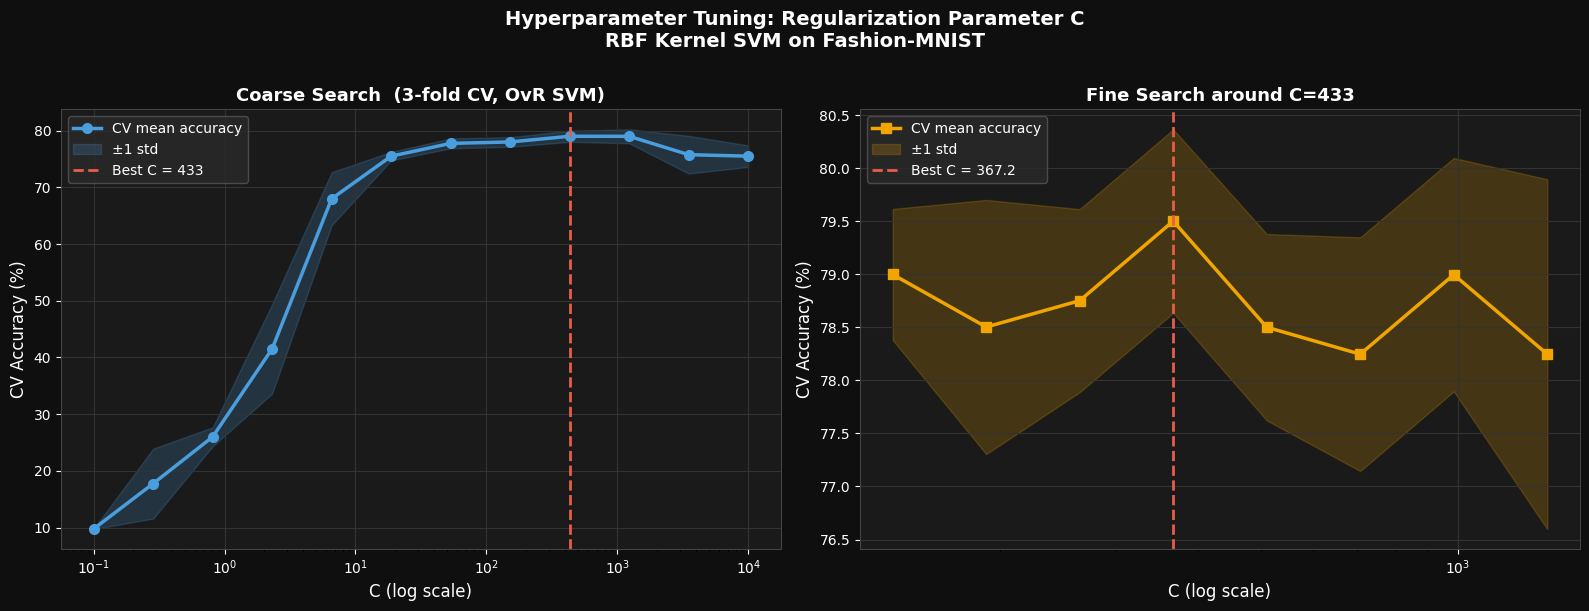

Figure saved → task4_C_tuning.png


In [34]:
# ─────────────────────────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

for ax in axes:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#444')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# ── Left: coarse log-space search ──
ax = axes[0]
ax.semilogx(C_values, cv_means * 100,
            color='#4a9edd', linewidth=2.5, marker='o',
            markersize=7, label='CV mean accuracy')
ax.fill_between(C_values,
                (cv_means - cv_stds) * 100,
                (cv_means + cv_stds) * 100,
                color='#4a9edd', alpha=0.2, label='±1 std')
ax.axvline(best_C, color='#e85d4a', linewidth=2,
           linestyle='--', label=f'Best C = {best_C:.3g}')
ax.set_xlabel('C (log scale)', fontsize=12)
ax.set_ylabel('CV Accuracy (%)', fontsize=12)
ax.set_title(f'Coarse Search  ({FOLDS}-fold CV, OvR SVM)',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a2a', labelcolor='white',
          edgecolor='#555', fontsize=10)
ax.grid(True, color='#333', linewidth=0.8)

# ── Right: fine search ──
ax = axes[1]
ax.semilogx(C_fine, cv_fine_m * 100,
            color='#f0a500', linewidth=2.5, marker='s',
            markersize=7, label='CV mean accuracy')
ax.fill_between(C_fine,
                (cv_fine_m - cv_fine_s) * 100,
                (cv_fine_m + cv_fine_s) * 100,
                color='#f0a500', alpha=0.2, label='±1 std')
ax.axvline(best_fine_C, color='#e85d4a', linewidth=2,
           linestyle='--', label=f'Best C = {best_fine_C:.4g}')
ax.set_xlabel('C (log scale)', fontsize=12)
ax.set_ylabel('CV Accuracy (%)', fontsize=12)
ax.set_title(f'Fine Search around C={best_C:.3g}',
             fontsize=13, fontweight='bold')
ax.legend(facecolor='#2a2a2a', labelcolor='white',
          edgecolor='#555', fontsize=10)
ax.grid(True, color='#333', linewidth=0.8)

fig.suptitle('Hyperparameter Tuning: Regularization Parameter C\n'
             'RBF Kernel SVM on Fashion-MNIST',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('task4_C_tuning.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Figure saved → task4_C_tuning.png")

In [35]:

# ─────────────────────────────────────────────────────────────────
# Summary for report
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TASK 4 REPORT SUMMARY")
print("=" * 60)
print(f"""
Strategy
--------
C was selected via {FOLDS}-fold stratified cross-validation on a
{TUNE_SAMPLES}-sample balanced subset of the training data, using
the One-vs-Rest scheme (faster than OvO for tuning).

Two-stage search:
  1. Coarse: np.logspace(-1, 4, 12)  →  C in [0.1, 10000]
  2. Fine  : np.logspace around best coarse C (±0.5 decades, 8 pts)

Result
------
  Coarse best C : {best_C:.3g}
  Fine   best C : {best_fine_C:.4g}

Interpretation
--------------
High C (low regularisation) forces the optimiser to correctly
classify as many training points as possible, accepting a narrower
margin. This is consistent with the hint and with Fashion-MNIST,
where the classes have complex, overlapping feature distributions
that benefit from a tighter fit rather than a wide soft margin.
Low C over-regularises: too many misclassified support vectors
reduce discriminative power across all 10 classes.
""")


TASK 4 REPORT SUMMARY

Strategy
--------
C was selected via 3-fold stratified cross-validation on a
400-sample balanced subset of the training data, using
the One-vs-Rest scheme (faster than OvO for tuning).

Two-stage search:
  1. Coarse: np.logspace(-1, 4, 12)  →  C in [0.1, 10000]
  2. Fine  : np.logspace around best coarse C (±0.5 decades, 8 pts)

Result
------
  Coarse best C : 433
  Fine   best C : 367.2

Interpretation
--------------
High C (low regularisation) forces the optimiser to correctly
classify as many training points as possible, accepting a narrower
margin. This is consistent with the hint and with Fashion-MNIST,
where the classes have complex, overlapping feature distributions
that benefit from a tighter fit rather than a wide soft margin.
Low C over-regularises: too many misclassified support vectors
reduce discriminative power across all 10 classes.



## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [37]:
# Simple confusion matrix computation
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
rbf_k     = lambda A, B: nonlinear_kernel(A, B, kernel='rbf', gamma=1e-4)

ovr_final = OneVsRestSVM(kernel=rbf_k, C=best_fine_C)
ovr_final.fit(train_samples.values / 255.0, train_samples_labels.values)

predictions = ovr_final.predict(test_samples.values / 255.0)


[1/10] OvR — class 0 (T-shirt/top) vs rest  (197 pos / 1603 neg)
 Fit complete — 300 support vectors, b = -7.4220
[2/10] OvR — class 1 (Trouser) vs rest  (182 pos / 1618 neg)
 Fit complete — 109 support vectors, b = -1.6093
[3/10] OvR — class 2 (Pullover) vs rest  (187 pos / 1613 neg)
 Fit complete — 391 support vectors, b = -11.0555
[4/10] OvR — class 3 (Dress) vs rest  (190 pos / 1610 neg)
 Fit complete — 253 support vectors, b = -19.1434
[5/10] OvR — class 4 (Coat) vs rest  (200 pos / 1600 neg)
 Fit complete — 325 support vectors, b = -12.3808
[6/10] OvR — class 5 (Sandal) vs rest  (160 pos / 1640 neg)
 Fit complete — 196 support vectors, b = 9.9812
[7/10] OvR — class 6 (Shirt) vs rest  (188 pos / 1612 neg)
 Fit complete — 454 support vectors, b = -25.9301
[8/10] OvR — class 7 (Sneaker) vs rest  (165 pos / 1635 neg)
 Fit complete — 172 support vectors, b = -15.5939
[9/10] OvR — class 8 (Bag) vs rest  (168 pos / 1632 neg)
 Fit complete — 152 support vectors, b = -13.4439
[10/10] OvR 

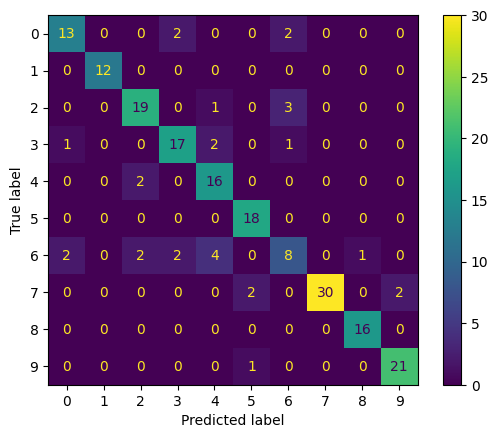

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.